# Historical assessment
In this notebook we evaluate the method's implementation over the training period to confirm it is behaving as expected and understand any limitations. We do this by answer the question "How does the dataset over the training period compare to the ERA5 dataset?" It should, by construction, align well, but this notebook evaluates how well they match, and when they differ, how they differ.

This notebook looks at:
- maps of different metrics
- timeseries for a set of individual locations to see pixel-level timeseries
- CDFs of individual locations to assess pixel-level performance

In [1]:
%load_ext autoreload
%autoreload 2
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog
from srm.plotting import (
    calculate_statistic_to_plot,
    locations,
    plot_4regions_comparisons,
    plot_comparisons,
    plot_timeseries,
    prep_datasets_for_seasonal_cycle_plotting,
    random_non_leap_year,
)

In [2]:
def icechunk_storage(path: str):
    """Create icechunk Storage from an S3 or local path."""
    if path.startswith("s3://"):
        path_no_scheme = path[len("s3://") :]
        bucket, _, prefix = path_no_scheme.partition("/")
        return icechunk.s3_storage(bucket=bucket, prefix=prefix)
    else:
        return icechunk.local_filesystem_storage(path=path)

In [3]:
def open_from_icechunk(path: str) -> xr.Dataset:
    """Open a dataset from an icechunk store."""
    storage = icechunk_storage(path)
    icechunk.Repository.open(storage)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    return xr.open_dataset(session.store, engine="zarr", consolidated=False, chunks={})

In [4]:
# historical
ds1 = open_from_icechunk(
    "s3://carbonplan-srm/output/qa/v0.6/historical/CESM2-WACCM/tas/r1i1p1f1/global/5e6b6f6c/historical.icechunk/"
)

ds2 = open_from_icechunk(
    "s3://carbonplan-srm/output/qa/v0.6/ssp245/CESM2-WACCM/tas/r1i1p1f1/global/5e6b6f6c/ssp245.icechunk/"
)

obs_regridded = open_from_icechunk(
    "s3://carbonplan-srm/output/qa/v0.6/obs/CESM2-WACCM/tas/global/obs_regridded.icechunk/"
)

In [5]:
variables = ["tas"]

In [6]:
era5 = catalog.get("ERA5").to_xarray()
era5 = era5[variables]

In [7]:
gcm = "CESM2-WACCM"  # TODO - once dataset name is fixed this should update to CESM2
scenario = "historical"  # "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
# @anderson - replace training period with full training period
# (matching the config you used to run the simulation)
# training_period = slice("1990-01-01", "1991-12-31")
training_period = slice("1978-01-01", "2014-12-31")
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.lon.max().values, ds2.lon.min().values
lat_max, lat_min = ds1.lat.max().values, ds1.lat.min().values

# this will restrict the domain to the spatial extent of ds2
lon_max, lon_min = ds2.lon.max().values, ds2.lon.min().values
lat_max, lat_min = ds2.lat.max().values, ds2.lat.min().values

In [8]:
raw = catalog.get(dataset_name).to_xarray()[variables]

In [9]:
# ds1 = ds1.sel(time=training_period)
# ds2 = ds2.sel(time=training_period)
# era5 = era5.sel(time=training_period)
# raw = raw.sel(time=training_period)
# obs_regridded = obs_regridded.sel(time=training_period)

# How well does downscaled historical temperature match ERA5 over the training period?

This analysis will see how well our downscaled data matches the data it was trained on and where it differs.

## mean temperature

In [10]:
raw_toplot, era5_toplot, ds1_toplot, _ = calculate_statistic_to_plot(
    raw.sel(time=training_period),
    era5.sel(time=training_period),
    ds1.sel(time=training_period),
    "mean",
    "tas",
    # ds2=ds2,
)

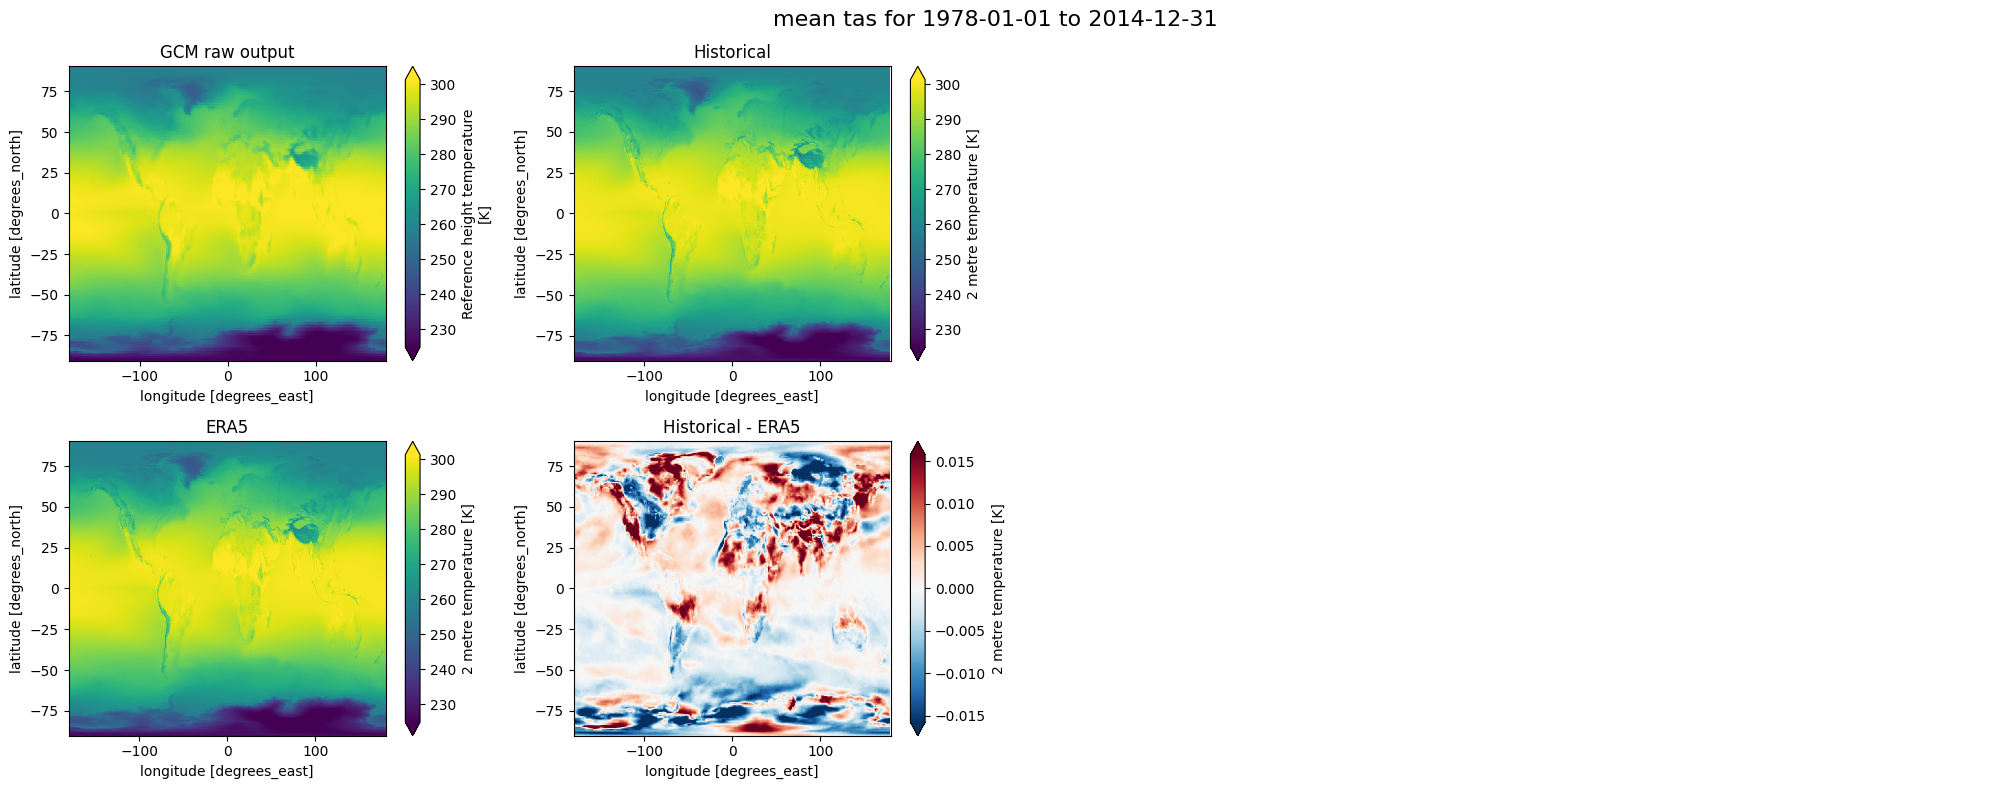

In [11]:
plot_comparisons(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    ds1_name="Historical",
    title=f"mean tas for {training_period.start} to {training_period.stop}",
)

## mean annual max

In [12]:
# @anderson for some reason i'm getting a memory error here, even when just subsetted to a year of data.
# i don't immediately see why it should have different behavior from "mean" calculated above.
raw_hottest_day_toplot, era5_hottest_day_toplot, ds1_hottest_day_toplot, ds2_hottest_day_toplot = (
    calculate_statistic_to_plot(
        raw.sel(time=training_period),
        era5.sel(time=training_period),
        ds1.sel(time=training_period),
        "hottest_day",
        "tas",
        # ds2_tas,
    )
)

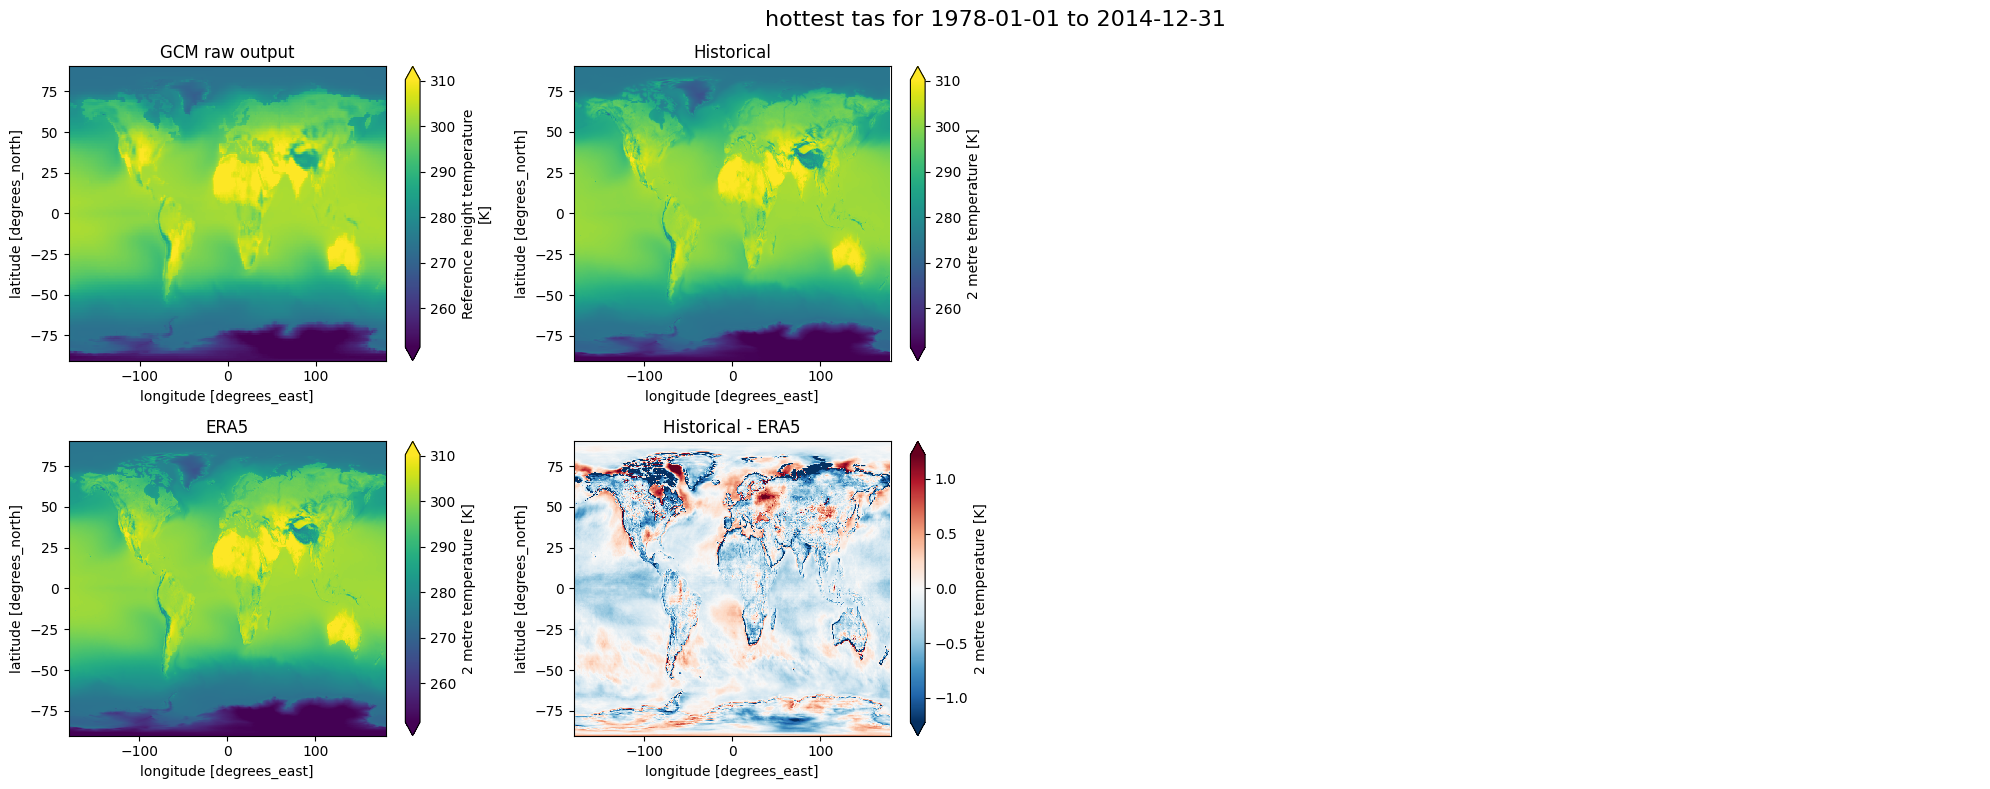

In [13]:
plot_comparisons(
    era5_hottest_day_toplot,
    raw_hottest_day_toplot,
    ds1_hottest_day_toplot,
    ds1_name="Historical",
    ds2=ds2_hottest_day_toplot,
    title=f"hottest tas for {training_period.start} to {training_period.stop}",
)

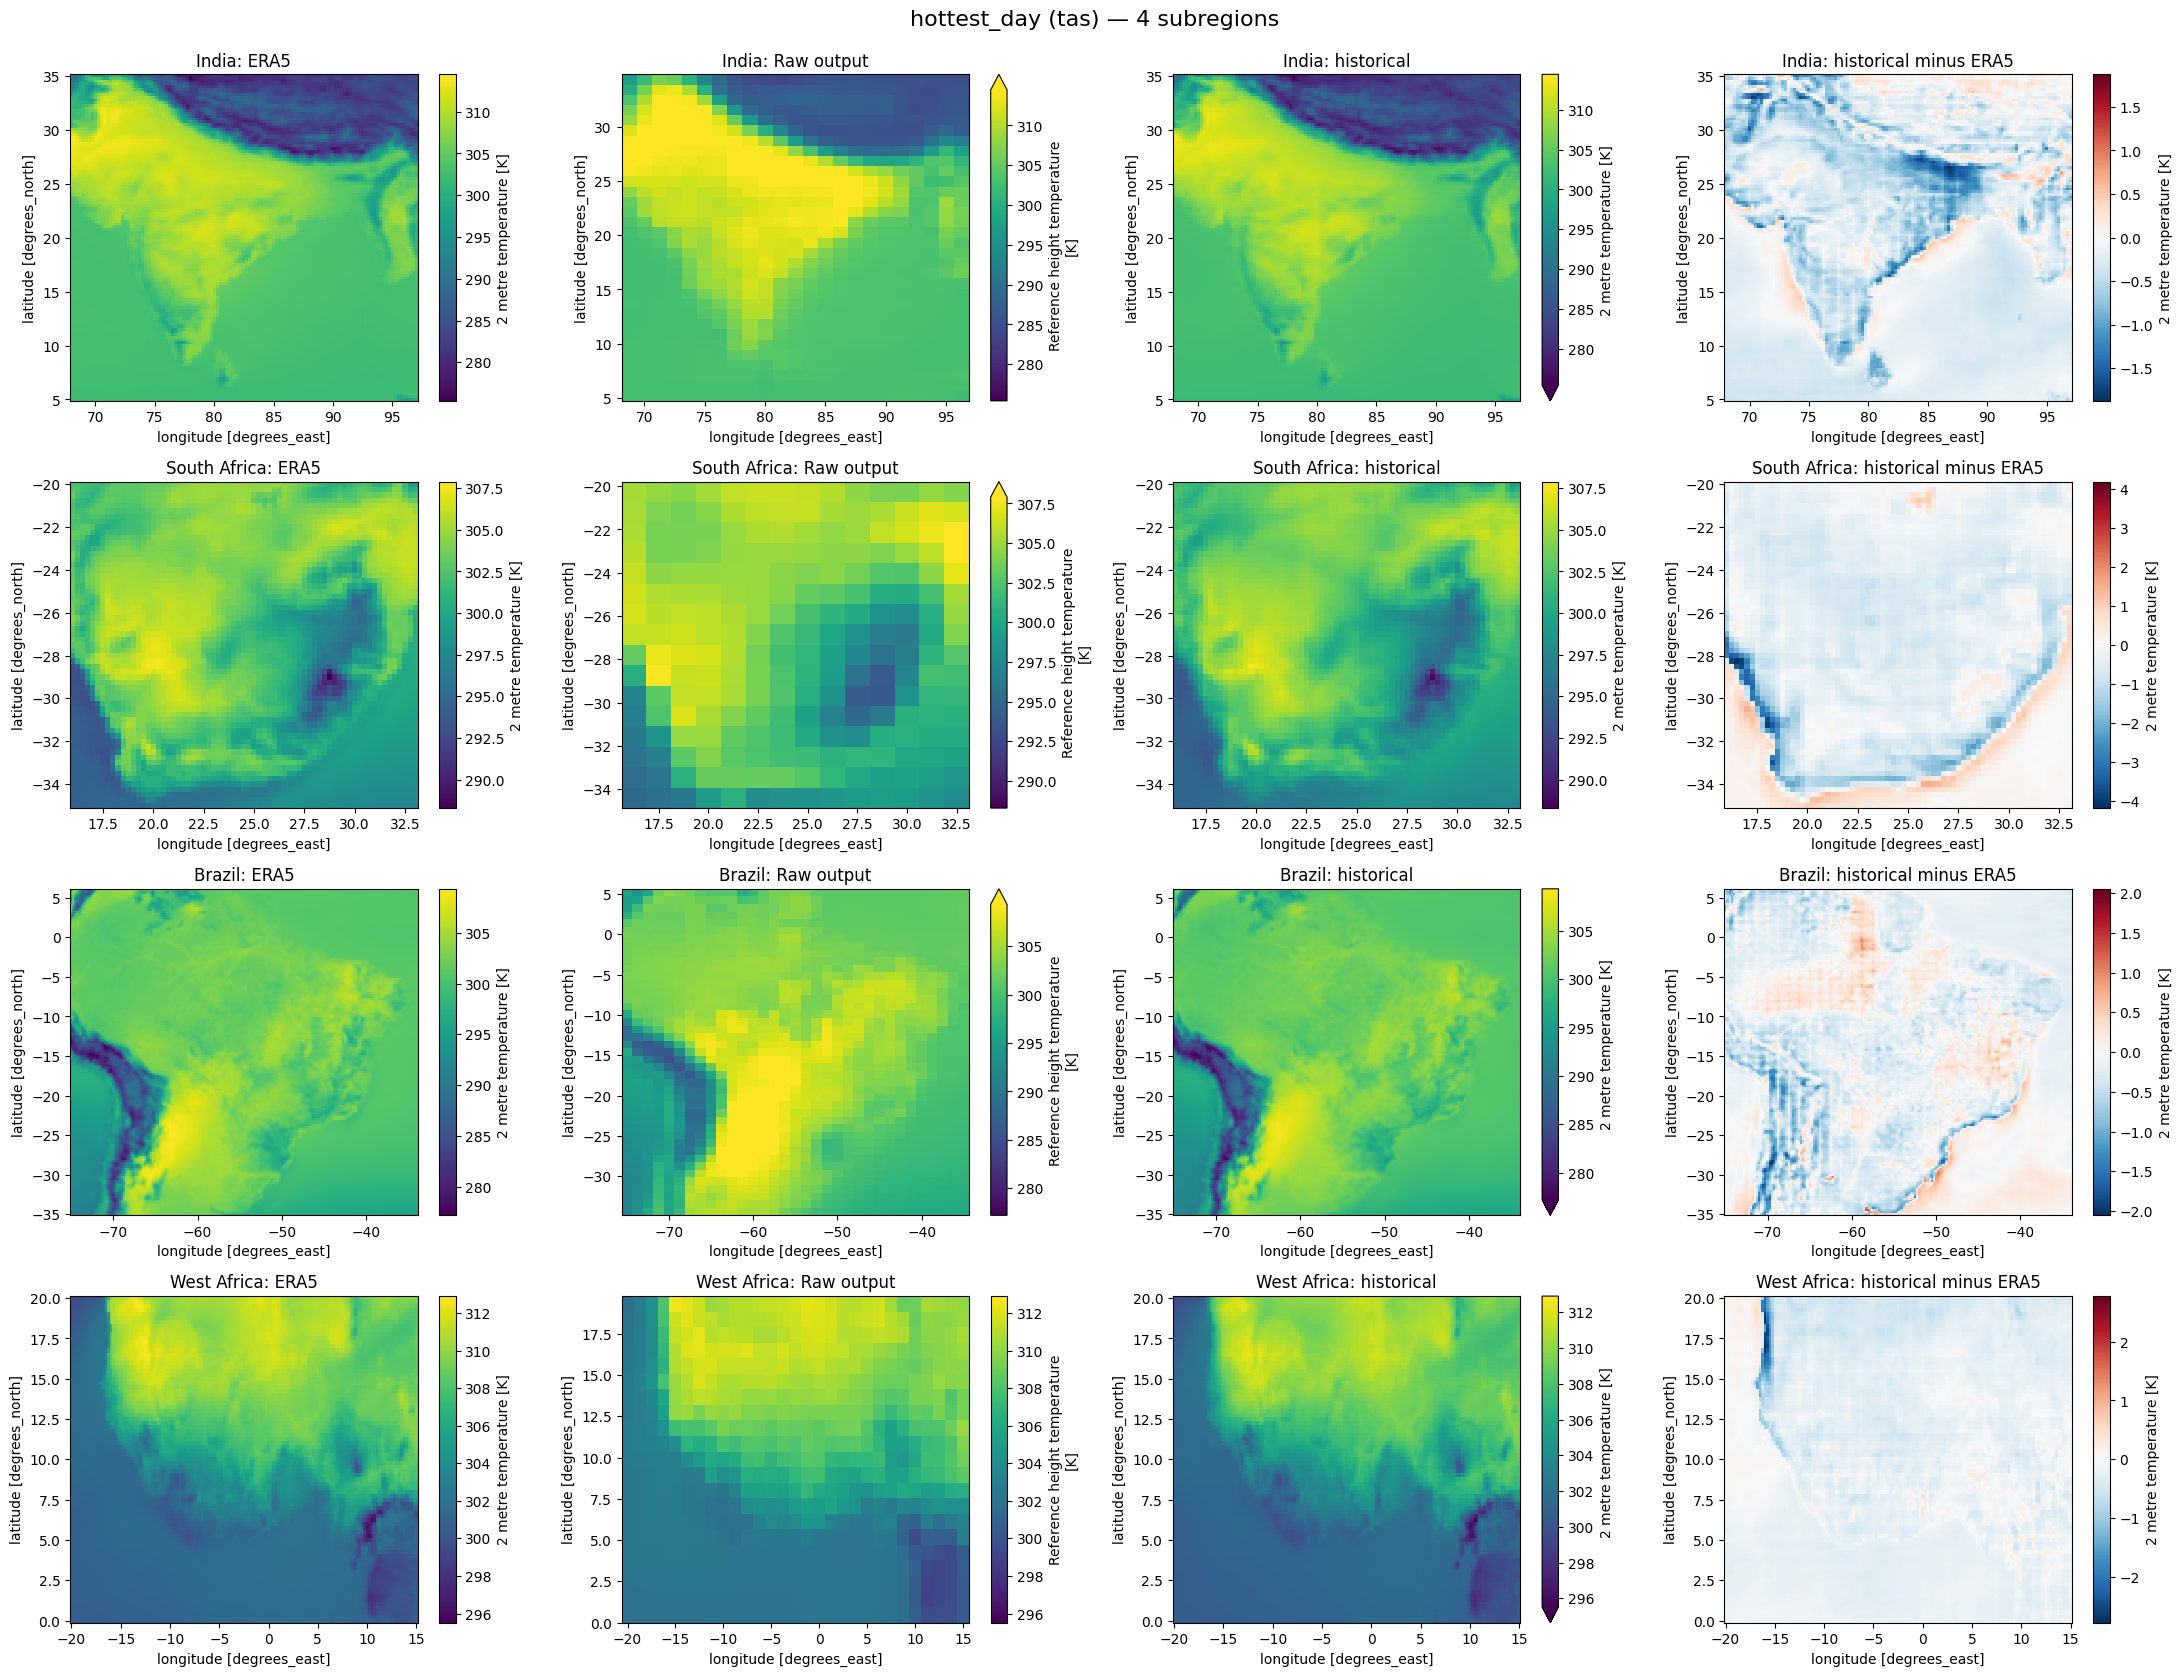

In [14]:
fig = plot_4regions_comparisons(
    raw=raw.sel(time=training_period),
    era5=era5.sel(time=training_period),
    ds1=ds1.sel(time=training_period),
    stat="hottest_day",
    variable="tas",
    ds1_title="historical",
)
plt.show()

## growing degree days

In [15]:
raw_gdd_toplot, era5_gdd_toplot, ds1_gdd_toplot, _ = calculate_statistic_to_plot(
    raw.sel(time=training_period),
    era5.sel(time=training_period),
    ds1.sel(time=training_period),
    "gdd",
    "tas",
)

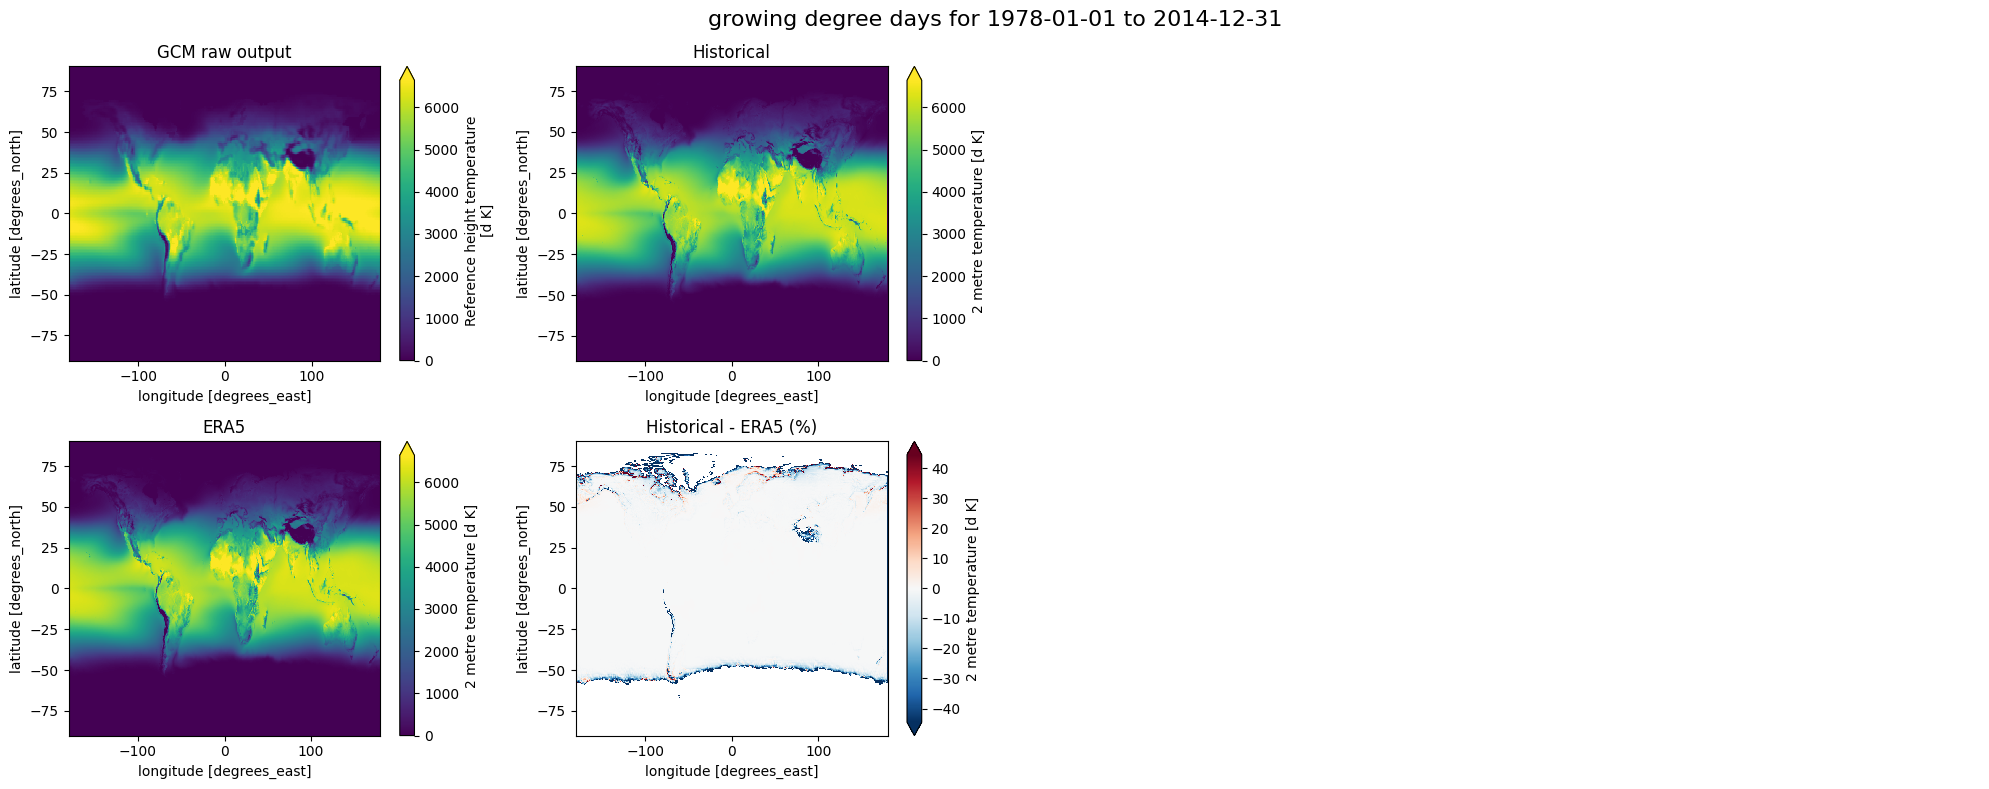

In [16]:
plot_comparisons(
    era5_gdd_toplot,
    raw_gdd_toplot,
    ds1_gdd_toplot,
    ds1_name="Historical",
    title=f"growing degree days for {training_period.start} to {training_period.stop}",
    bias="percentage",
)

In [17]:
raw_over30C_toplot, era5_over30C_toplot, ds1_over30C_toplot, _ = calculate_statistic_to_plot(
    raw.sel(time=training_period),
    era5.sel(time=training_period),
    ds1.sel(time=training_period),
    "days_over_30C",
    "tas",
)

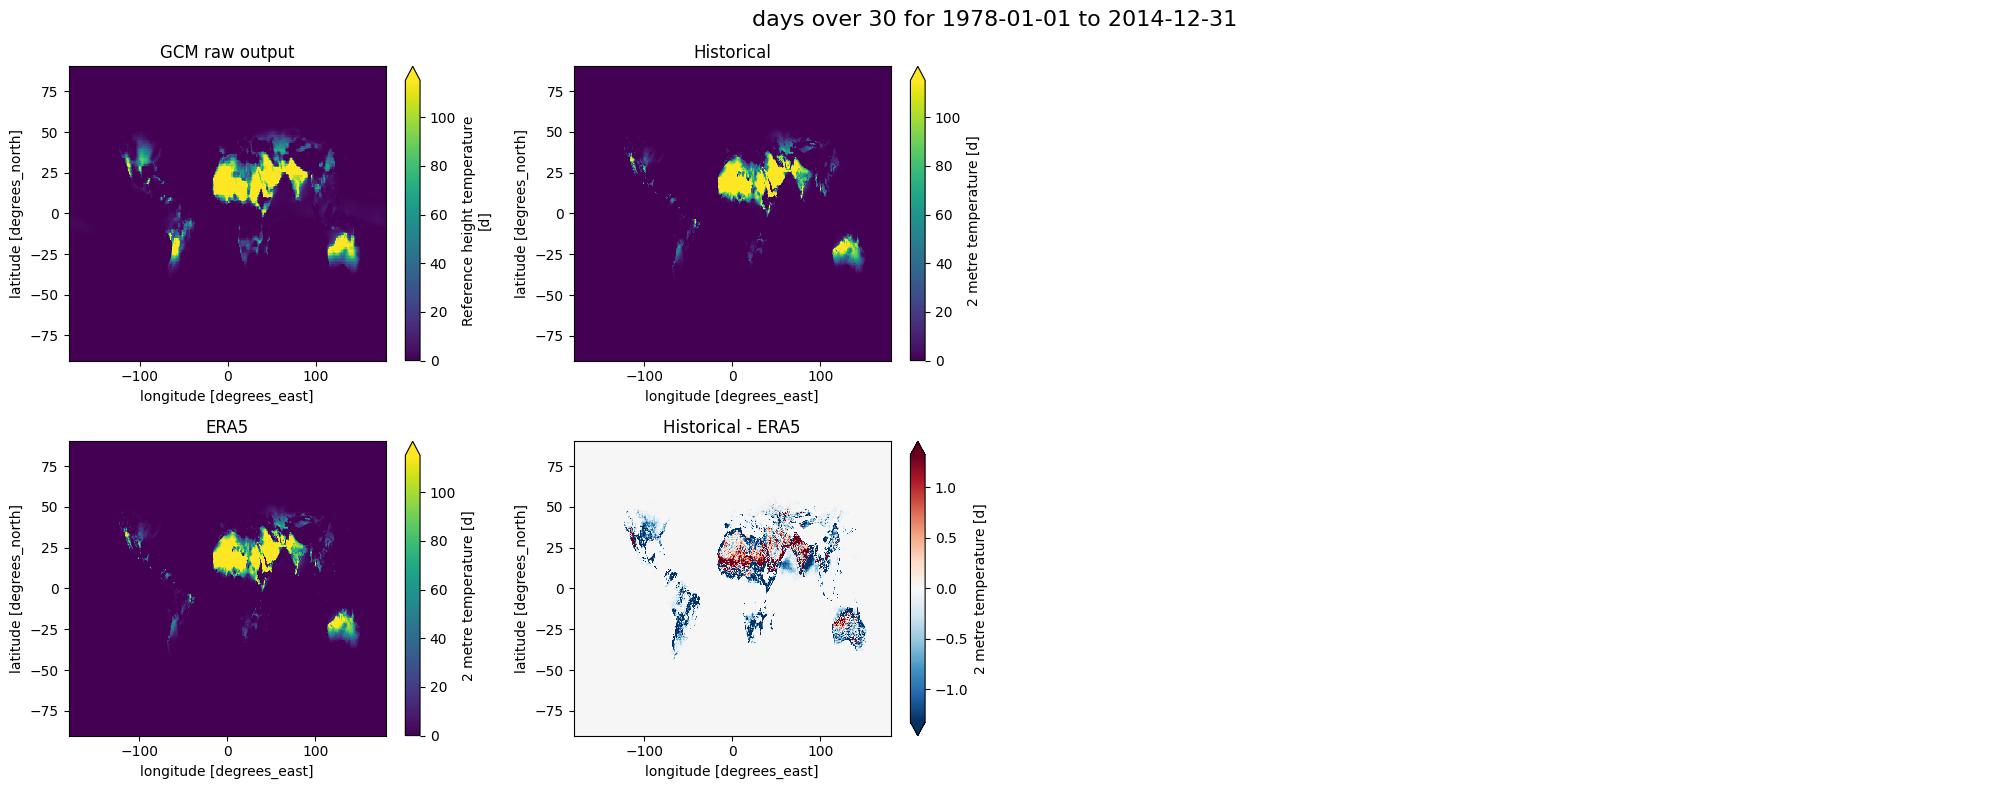

In [18]:
plot_comparisons(
    era5_over30C_toplot,
    raw_over30C_toplot,
    ds1_over30C_toplot,
    ds1_name="Historical",
    title=f"days over 30 for {training_period.start} to {training_period.stop}",
)

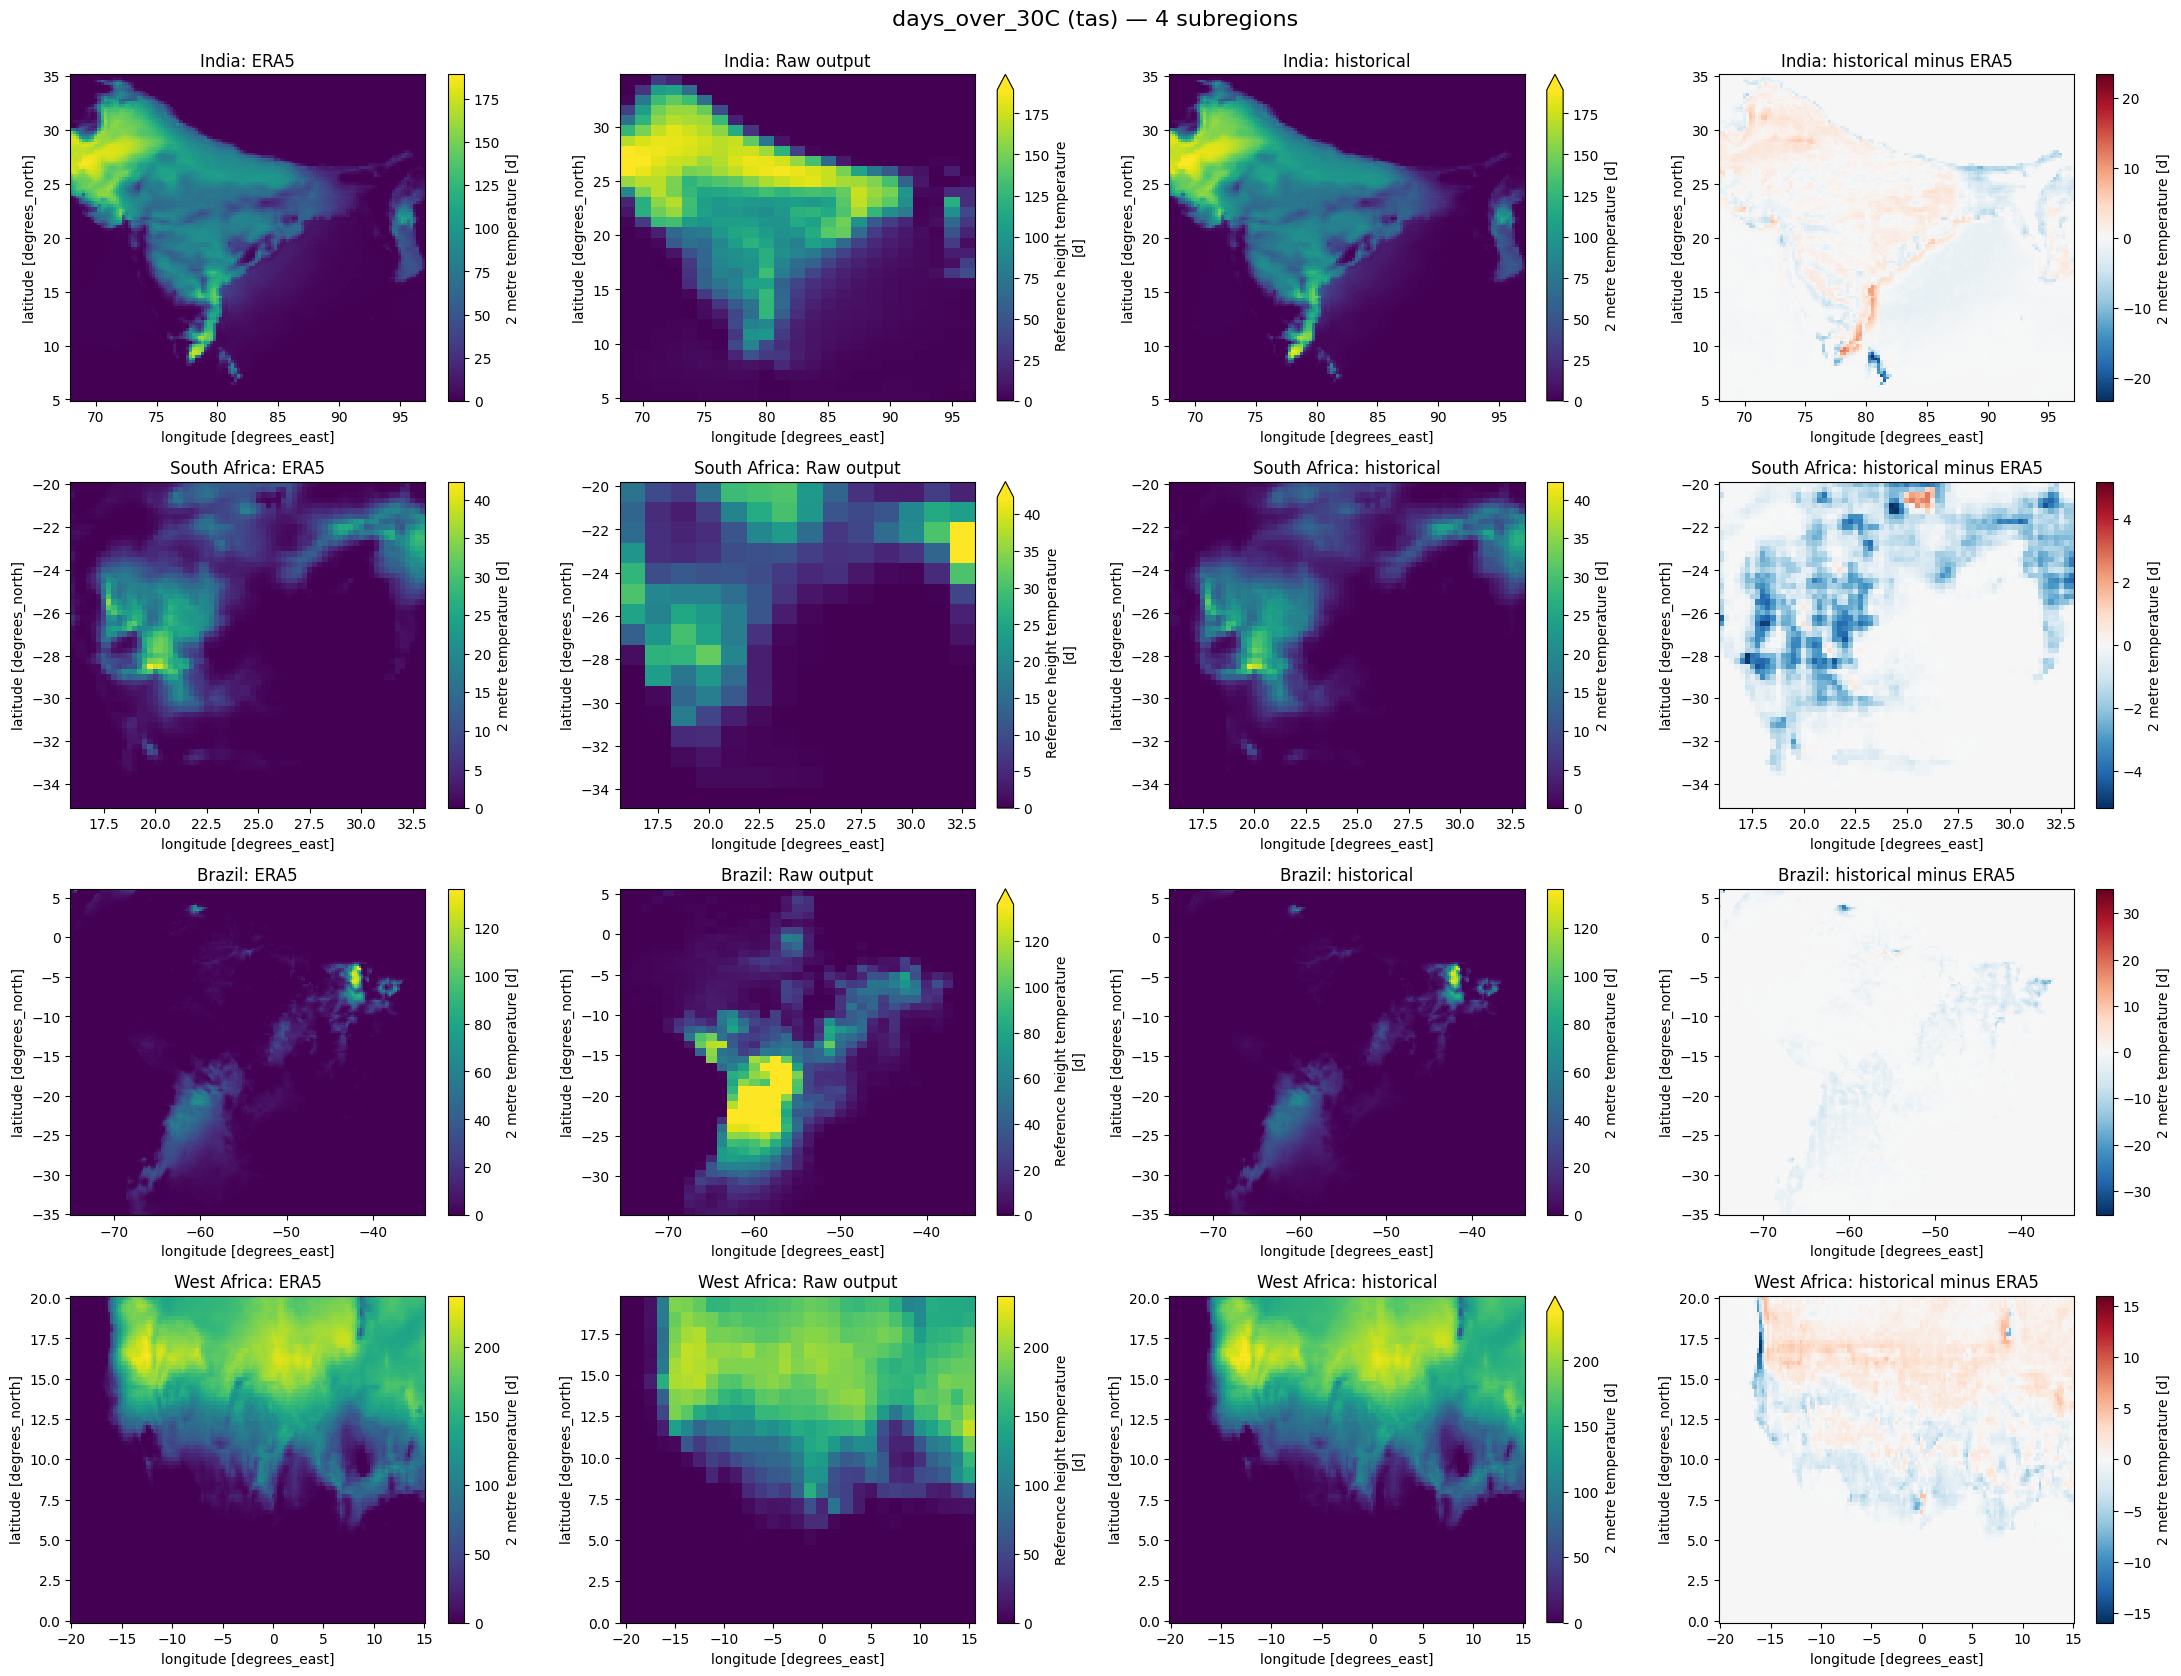

In [19]:
fig = plot_4regions_comparisons(
    raw=raw.sel(time=training_period),
    era5=era5.sel(time=training_period),
    ds1=ds1.sel(time=training_period),
    stat="days_over_30C",
    variable="tas",
    ds1_title="historical",
)
plt.show()

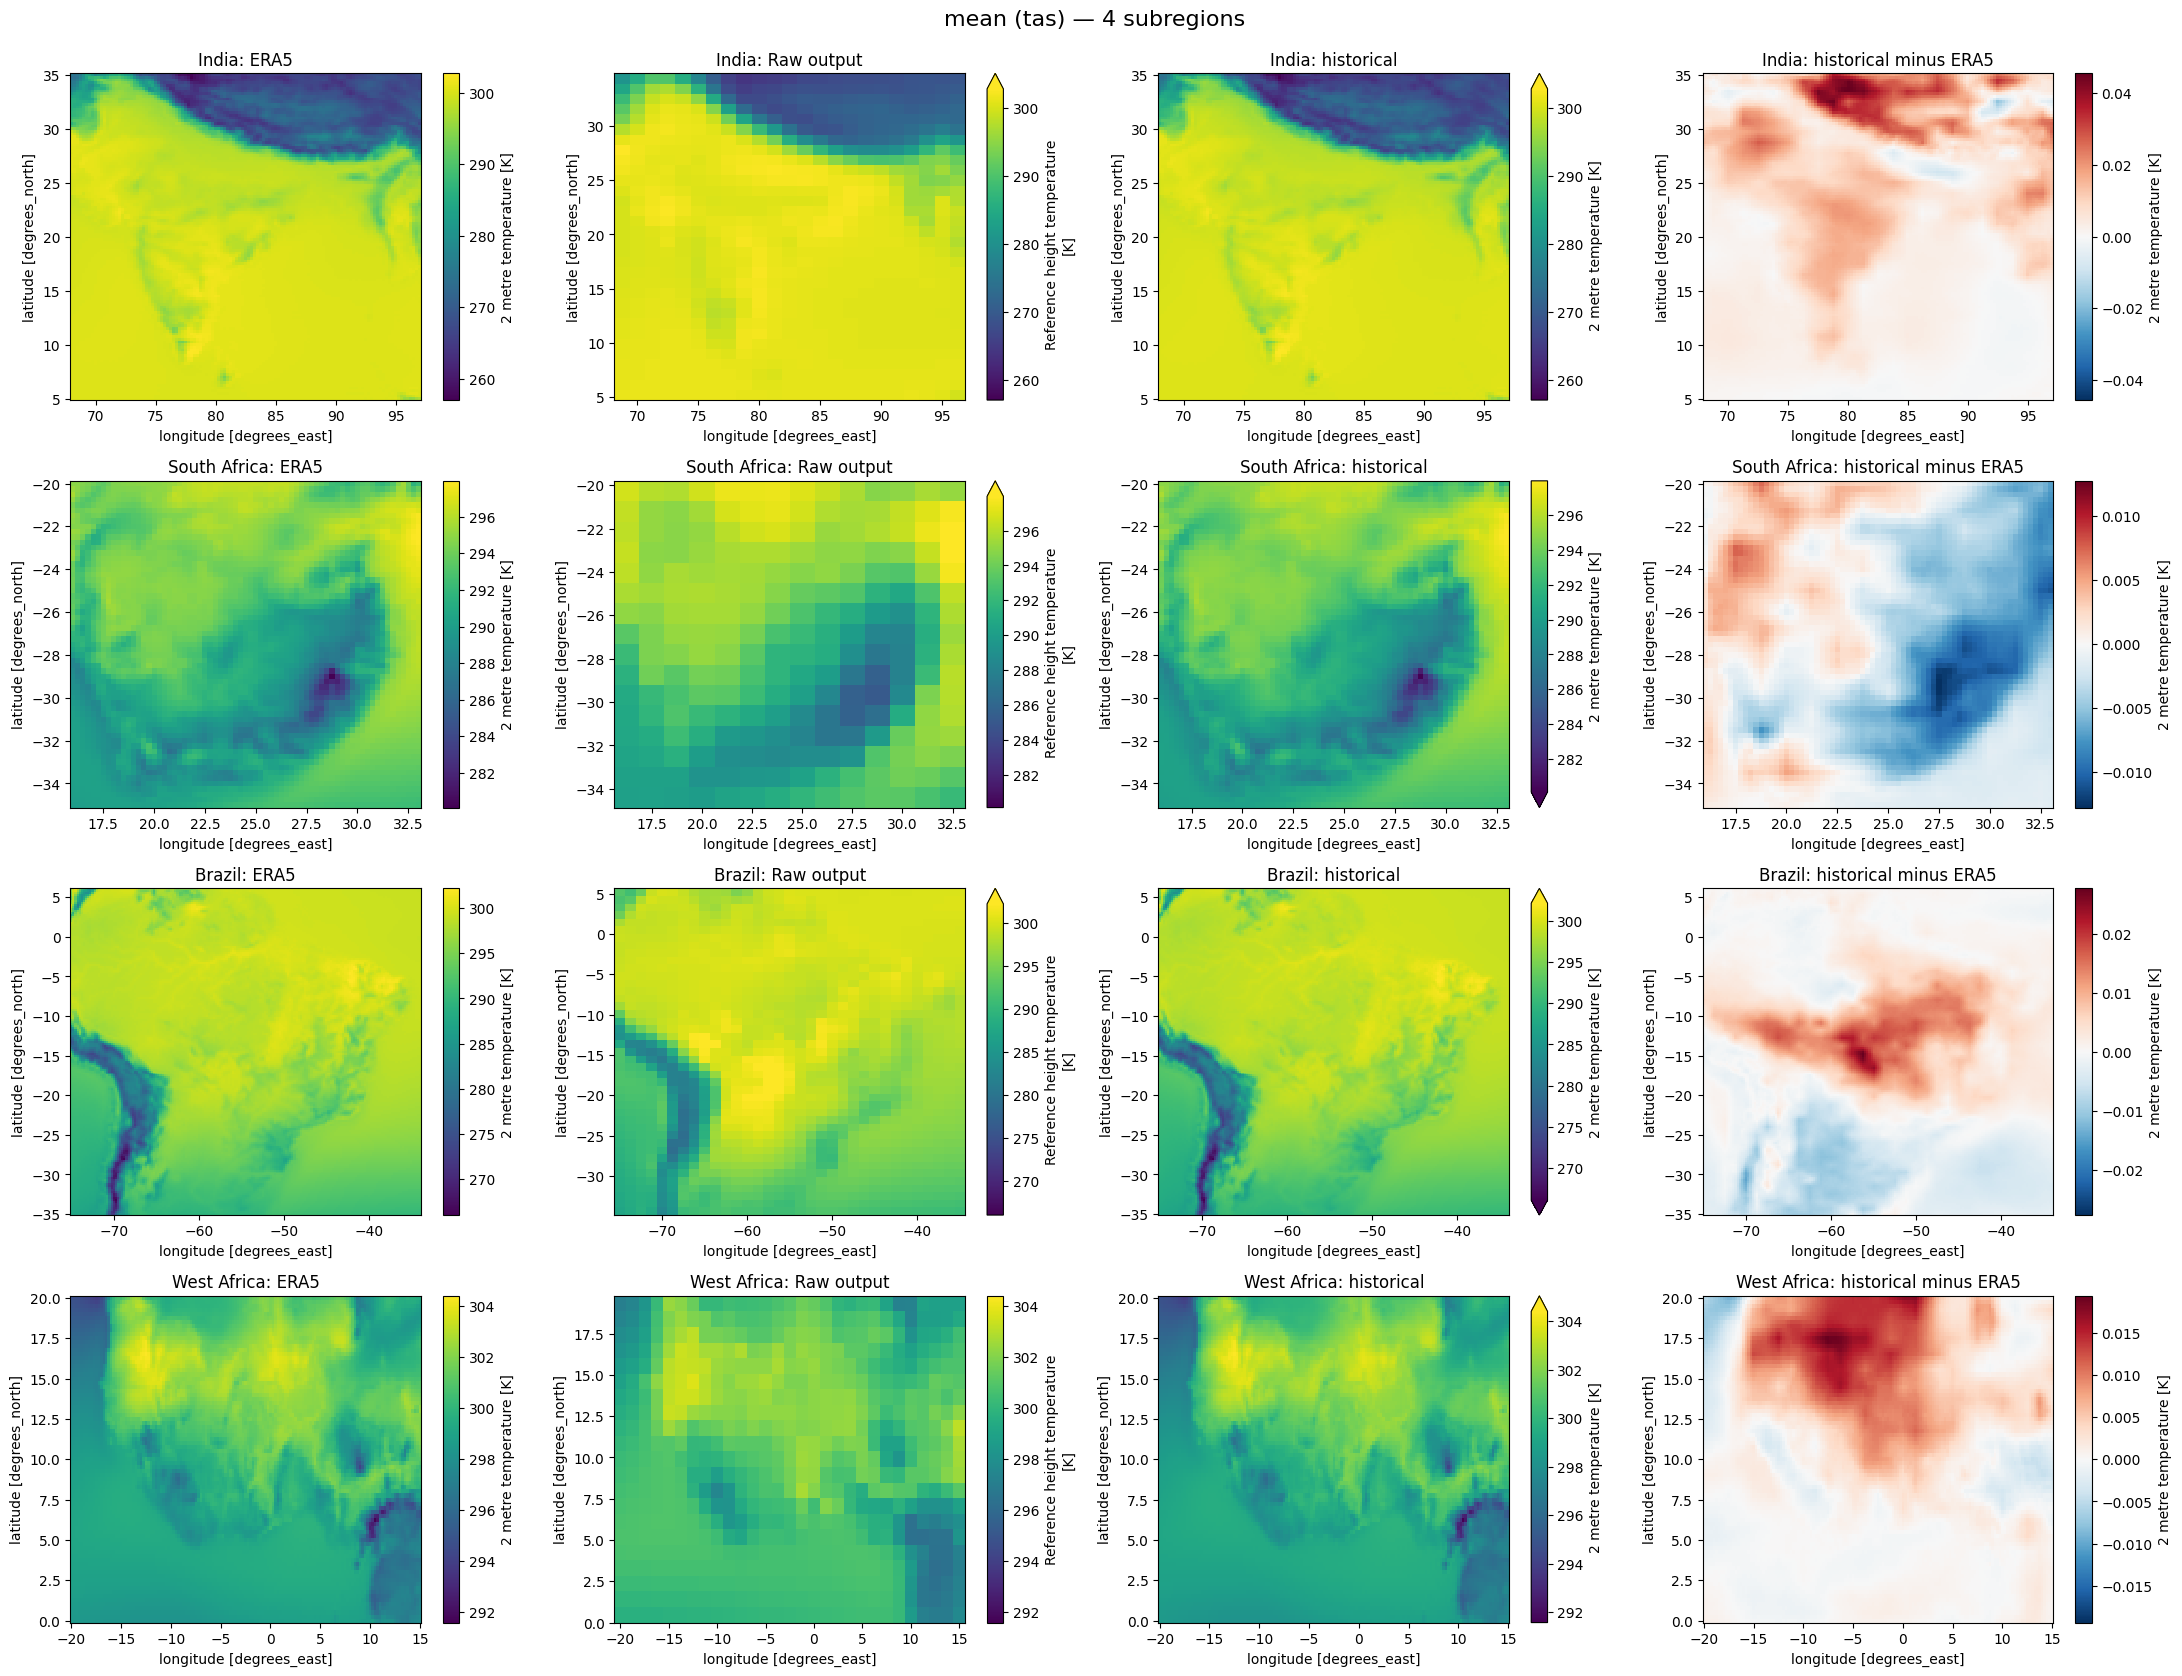

In [20]:
fig = plot_4regions_comparisons(
    raw=raw.sel(time=training_period),
    era5=era5.sel(time=training_period),
    ds1=ds1.sel(time=training_period),
    stat="mean",
    variable="tas",
    ds1_title="historical",
)
plt.show()

In [21]:
# Timeseries

In [22]:
ds1 = ds1.sel(time=training_period)
ds2 = ds2.sel(time=training_period)
era5 = era5.sel(time=training_period)
raw = raw.sel(time=training_period)

KeyError: "No variable named 'pr'. Variables on the dataset include ['tas', 'lat', 'lon', 'time']"

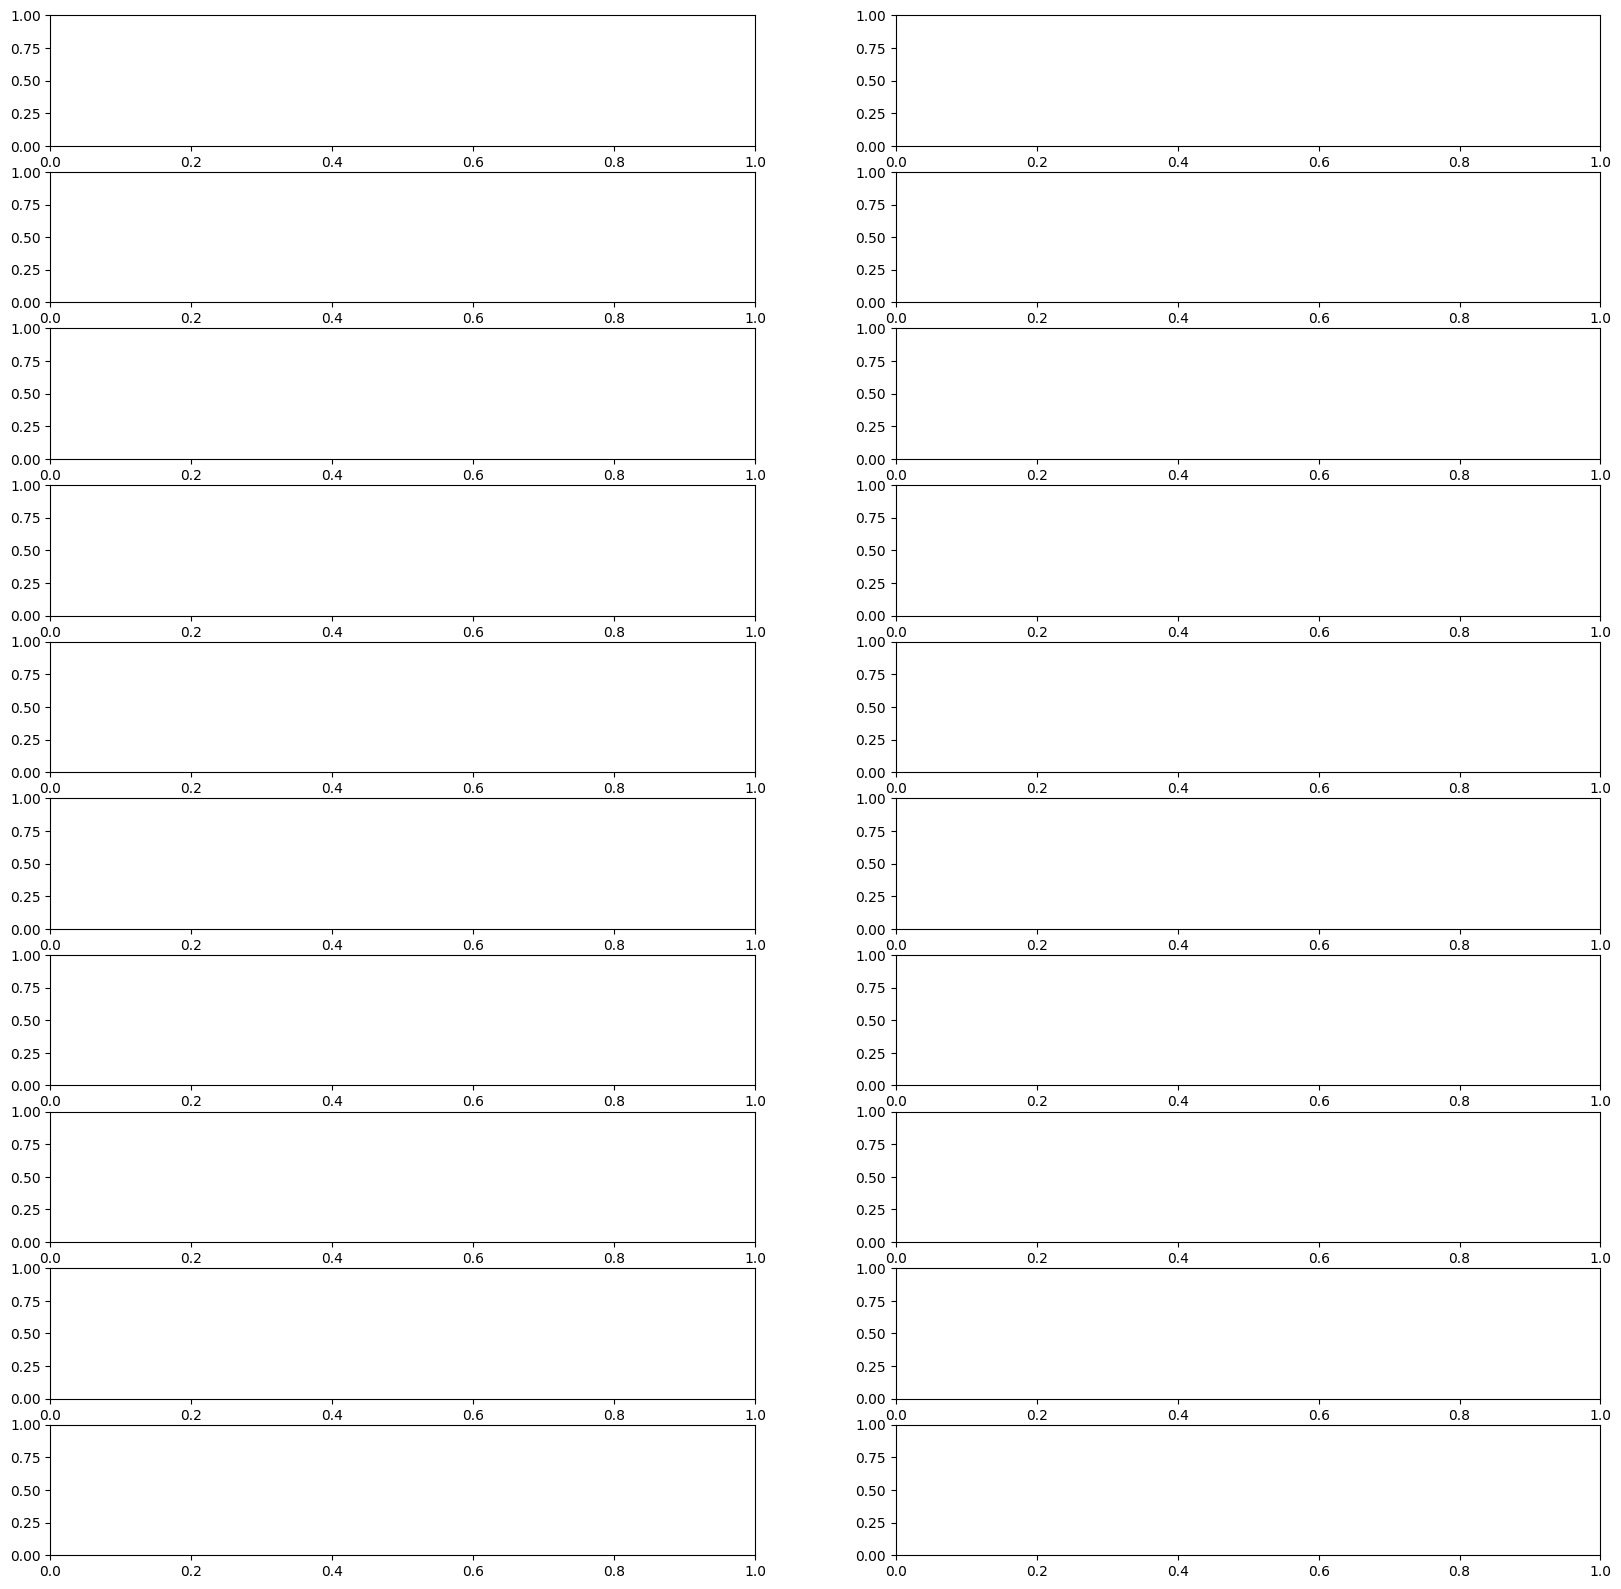

In [23]:
# temi TODO: add three more cells in this notebook, repeating these seasonal cycle plots for tasmax, tasmin, and tas
variable = "pr"
time_slice = slice("1984", "1984")

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_seasonal_cycle_plotting(
        era5, raw, ds1, time_slice, lat, lon, variable, ds2=ds2
    )

    plot_timeseries(axarr[i], era5_toplot, raw_toplot, ds1_toplot, location, ds2_toplot)
    axarr[i].set_title(location)
    axarr[i].set_ylabel("Precipitation (mm/day)")

fig.suptitle(
    f"Seasonal Cycle: {variable} ({time_slice.start}-{time_slice.stop})", fontsize=16, y=1.02
)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
# temi TODO: add a single legend applying to all of the panels of plots, above the figure
# temi TODO: add a title at the top of this figure (as part of the function) describing the variable and time period
# temi TODO: fix ylabels to have units

In [ ]:
# Make a figure with all of the timeseries for all of the locations for the same time slice
# Repeat for a randomly selected year - for ease of calendar use only choose non-leap year calendars

In [ ]:
ds_list = [era5, raw, ds1, ds2]

In [ ]:
variable = "pr"
random_year = random_non_leap_year()
time_slice = slice(str(random_year), str(random_year))

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    # First select time, THEN select point with method='nearest'
    era5_sub = era5.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    raw_sub = raw.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    ds1_sub = ds1.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    ds2_sub = ds2.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")

    # Plot using .values to avoid datetime issues
    axarr[i].plot(era5_sub[variable].values, color="grey", alpha=0.5)
    axarr[i].plot(raw_sub[variable].values, color="k")
    axarr[i].plot(ds1_sub[variable].values, color="firebrick")
    axarr[i].plot(ds2_sub[variable].values, color="royalblue")

    axarr[i].set_title(location)
    axarr[i].set_ylabel("Precipitation (mm/day)")
    axarr[i].set_xlabel("Day of Year")

fig.suptitle(
    f"Daily Timeseries: {variable} ({time_slice.start}-{time_slice.stop})", fontsize=16, y=1.02
)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

In [ ]:
# temi TODO: repeat the PDF figures (and update/extend the `plot_pdf` function as needed) for tasmax, tasmin, tas

A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.